In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
# Activation Function (Linear Hypothesis)
def linear_hypothesis(X, weights, bias):
    return np.dot(X, weights) + bias

In [3]:
# Initialize weights and bias
def initialize_weights(n_features):
    weights = np.zeros(n_features)
    bias = 0
    return weights, bias

In [4]:
# Compute Cost (Mean Squared Error)
def compute_cost(y, y_pred):
    m = len(y)
    cost = (1 / (2 * m)) * np.sum((y_pred - y) ** 2)
    return cost

In [5]:
# Compute Gradients
def compute_gradients(X, y, y_pred):
    m = len(y)
    dw = (1 / m) * np.dot(X.T, (y_pred - y))
    db = (1 / m) * np.sum(y_pred - y)
    return dw, db

In [6]:
# Train Linear Regression Model
def train_linear_regression(X, y, learning_rate=0.01, n_iterations=1000):
    n_features = X.shape[1]
    weights, bias = initialize_weights(n_features)
    cost_history = []
    for i in range(n_iterations):
        y_pred = linear_hypothesis(X, weights, bias)
        cost = compute_cost(y, y_pred)
        cost_history.append(cost)
        dw, db = compute_gradients(X, y, y_pred)
        weights -= learning_rate * dw
        bias -= learning_rate * db

    return weights, bias, cost_history

In [7]:
# Prediction Function
def predict(X, weights, bias):
    return linear_hypothesis(X, weights, bias)

In [8]:
# Evaluation Function (R-squared)
def evaluate_model(y_true, y_pred):
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_residual = np.sum((y_true - y_pred) ** 2)
    r_squared = 1 - (ss_residual / ss_total)
    return r_squared

In [9]:
np.random.seed(42)

data = {
    "Experience_Years": np.random.randint(0, 20, size=100),
    "Certifications": np.random.choice(["Yes", "No"], size=100),
    "Skill_Score": np.random.randint(30, 100, size=100),
    "Required_Skill_Score": np.random.randint(40, 100, size=100),
    "Gap_Level": np.random.randint(0, 30, size=100)
}

df = pd.DataFrame(data)
df.to_csv("Skill_Gap_Regression_Data.csv", index=False)
print("Synthetic dataset saved as 'Skill_Gap_Regression_Data.csv'")

Synthetic dataset saved as 'Skill_Gap_Regression_Data.csv'


In [10]:
# Load the Data
data = pd.read_csv('Skill_Gap_Regression_Data.csv')

In [11]:
# Data Preprocessing
# Example dataset transformations (adjust based on your dataset)
data['Experience_Years'] = pd.to_numeric(data['Experience_Years'], errors='coerce')
data['Certifications'] = data['Certifications'].map({'Yes': 1, 'No': 0})
data['Skill_Score'] = pd.to_numeric(data['Skill_Score'], errors='coerce')
data['Required_Skill_Score'] = pd.to_numeric(data['Required_Skill_Score'], errors='coerce')


In [12]:
# Select features and target variable
X = data[['Experience_Years', 'Certifications', 'Skill_Score', 'Required_Skill_Score']]
y = data['Gap_Level']  # Target variable (continuous value)


In [13]:
# Drop rows with missing values
X.dropna(inplace=True)
y = y[X.index.isin(X.dropna().index)]


C:\Users\nithi\AppData\Local\Temp\ipykernel_30272\1251043264.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.dropna(inplace=True)


In [14]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, test_size=0.2, random_state=42)


In [15]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
# Train the model
weights, bias, cost_history = train_linear_regression(X_train_scaled, y_train, learning_rate=0.01, n_iterations=1000)


In [17]:
# Make predictions
y_pred = predict(X_test_scaled, weights, bias)


In [18]:
print(y_pred)

[14.74958803 14.28036471 14.60032499 15.54843366 15.88988561 15.84603833
 16.97670259 14.56209029 13.08903608 18.36166986 17.08490352 15.74463813
 13.9886515  15.24103548 17.15173821 16.28031451 17.50911803 17.52218113
 19.07151064 17.79742153]


In [19]:
# Evaluate the model
r_squared = evaluate_model(y_test, y_pred)
print(f"R-squared: {r_squared:.2f}")

R-squared: -0.03


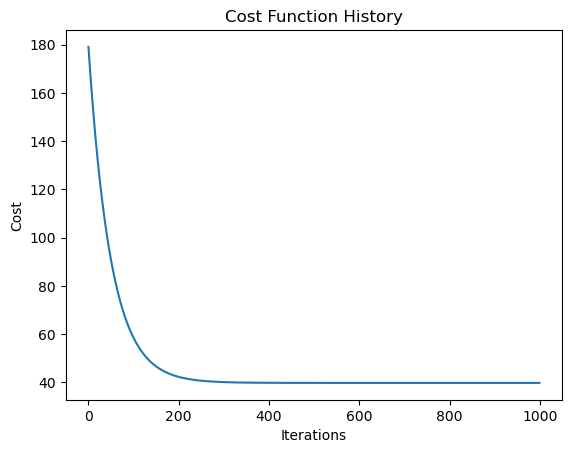

In [20]:
# Plot Cost Function History
plt.plot(cost_history)
plt.title("Cost Function History")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()
